<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/Lichess_Anomaly_Cheating_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Step 1: Import Libraries & Upload Data


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# For uploading CSV file from your local system
from google.colab import files
uploaded = files.upload()

# Load the CSV file
filename = next(iter(uploaded))
df = pd.read_csv(filename)
df.head()


Saving games.csv to games (2).csv


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


✅ Step 2: Create Rating Gap Column


In [5]:
# Rating gap: how much stronger the white player is (positive = white stronger)
df['rating_gap'] = df['white_rating'] - df['black_rating']


✅ Step 3: Define “Upset” (lower-rated player wins)


In [6]:
def is_upset(row):
    if row['winner'] == 'white' and row['rating_gap'] < -300:
        return True
    elif row['winner'] == 'black' and row['rating_gap'] > 300:
        return True
    else:
        return False

df['is_upset'] = df.apply(is_upset, axis=1)


✅ Step 3: Add “Short Upset” Indicator (suspicious)


In [7]:
# Short games that are also upsets are more suspicious
df['short_upset'] = df['is_upset'] & (df['turns'] <= 20)


✅ Step 4: Display Top Suspicious Games


In [8]:
# Show the most suspicious games
suspicious_games = df[df['short_upset']][[
    'id', 'white_id', 'white_rating', 'black_id', 'black_rating',
    'winner', 'turns', 'opening_name'
]]

# Display top 10
suspicious_games.head(10)


,id,white_id,white_rating,black_id,black_rating,winner,turns,opening_name
733,hh4qc2VN,theanonymousone,1362,hero100,976,black,18,Russian Game: Damiano Variation
741,DUjvd9GQ,slon-al,1810,shairo08,1495,black,20,Elephant Gambit: Paulsen Countergambit
1006,hyCmLj7A,aidenleahycrooks,1862,melvet,1416,black,18,Pirc Defense #2
1433,8VrFmBra,sesh,1678,poetrunner,1017,black,17,Philidor Defense #3
1484,MeJ86Rct,losteroo,1237,zixi52,1565,white,19,Italian Game: Two Knights Defense | Traxler C...
1543,Igw3bRib,victor946c,1161,ranger440,1472,white,6,Old Indian Defense
1967,uhsgwEWX,sveenemand,1091,anotol,1701,white,2,Van't Kruijs Opening
2008,NUxCVtS8,homesteadpost,1382,mimirilinguis,1009,black,14,Kadas Opening
3372,HT5qFt31,bonusminus,1480,mailsupriya,1815,white,19,Sicilian Defense: O'Kelly Variation | Normal ...
3554,53nOG42b,toni90,1081,rps_1899,2126,white,3,King's Knight Opening


✅ Step 6: Visualize Upset Game Lengths vs Normal Games



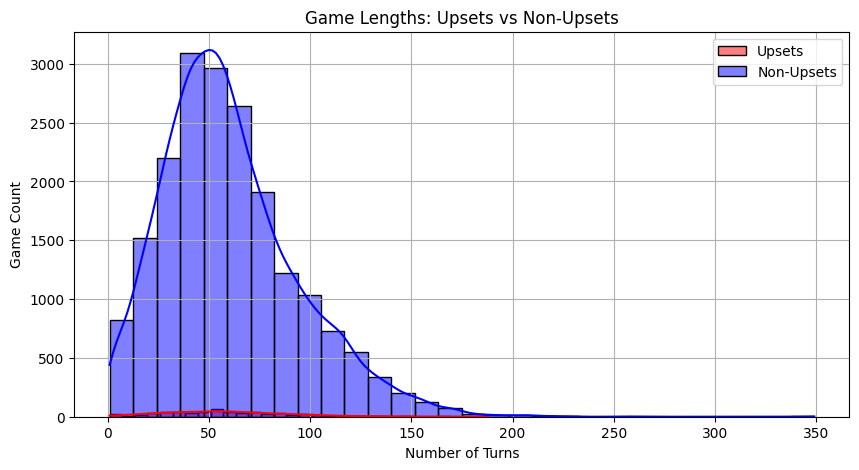

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df[df['is_upset']]['turns'], bins=30, color='red', label='Upsets', kde=True)
sns.histplot(df[~df['is_upset']]['turns'], bins=30, color='blue', label='Non-Upsets', kde=True, alpha=0.5)
plt.legend()
plt.title("Game Lengths: Upsets vs Non-Upsets")
plt.xlabel("Number of Turns")
plt.ylabel("Game Count")
plt.grid(True)
plt.show()

Step 7: Count Suspicious Games

In [10]:
print("Total suspicious (short upset) games:", df['short_upset'].sum())


Total suspicious (short upset) games: 55
